In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install pydub

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
from pydub import AudioSegment
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from scipy.stats import kurtosis
from scipy.signal import find_peaks

In [ ]:
# Function to convert M4A to WAV using pydub
def convert_m4a_to_wav(audio_path, output_path):
    audio = AudioSegment.from_file(audio_path, format="m4a")
    audio.export(output_path, format="wav")

In [ ]:
from scipy.signal import butter, lfilter, freqz, filtfilt, find_peaks

def butter_bandpass(lowcut, highcut, fs, order=5):
    return butter(order, [lowcut, highcut], fs=fs, btype='band')

def butter_bandpass_filter(data, lowcut, highcut, fs, order=5):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = lfilter(b, a, data)
    return y


def plot_filtered_signal(tap_signal,sr): #Bandpass filter
    # Sample rate and desired cutoff frequencies (in Hz).
    fs = sr
    lowcut = 20
    highcut = 20000

    n = len(tap_signal) # indicates total samples
    t = np.linspace(0, n,n)
#     plt.figure(figsize=(15,8))
#     plt.clf()
#     plt.plot(t, tap_signal, label='Noisy signal')

    y = butter_bandpass_filter(tap_signal, lowcut, highcut, fs, order=3)
#     plt.plot(t, y, label='Filtered signal ( Hz)')
#     plt.xlabel('time (seconds)')
#     plt.legend(loc='upper left')

#     plt.show()
    return y

In [ ]:
import os
import soundfile as sf

def split_and_save_audio(audio_folder, output_folder):
    audio_files = [os.path.join(audio_folder, f) for f in os.listdir(audio_folder) if f.endswith('.m4a')]

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    for audio_file in audio_files:
        filename = os.path.splitext(os.path.basename(audio_file))[0]
        label = filename.split('_')[0]

        # Convert M4A to WAV
        wav_file = os.path.join(output_folder, f"{filename}.wav")
        convert_m4a_to_wav(audio_file, wav_file)

        # Load audio data and sample rate using librosa
        audio, sr = librosa.load(wav_file, sr=None, mono=False)

        # Process each channel separately (assuming stereo audio)
        for channel in range(audio.shape[0]):
            current_channel = audio[channel, :]

            # Apply bandpass filtering to the current channel
            filtered_signal = plot_filtered_signal(current_channel, sr)

            # Find peaks in the audio
            peaks, _ = find_peaks(filtered_signal)

            # Get the sample indices and values of the highest peak
            highest_peak_index = peaks[np.argmax(filtered_signal[peaks])]
            highest_peak_value = filtered_signal[highest_peak_index]

            # Calculate height, distance, and splitRange
            height = highest_peak_value / 2
            distance = 550
            splitRange = distance // 2

            # Peak Finding with height and distance parameters
            peaks, _ = find_peaks(filtered_signal, height=height, distance=distance)

            # Split and save segments
            for i, peak in enumerate(peaks):
                if i == 0:
                    segment = current_channel[:peak]
                elif i == len(peaks) - 1:
                    segment = current_channel[peak:]
                else:
                    segment = current_channel[peak:peaks[i + 1]]

                output_file = os.path.join(output_folder, f'{label}_segment_{i}.wav')
                sf.write(output_file, segment, sr)

    print(f"Segments saved in {output_folder}")


In [ ]:
audio_path = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Train'
output_folder = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios'

split_and_save_audio(audio_path, output_folder)

Segments saved in /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios


In [ ]:
audio_path = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Test'
output_folder = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test'

split_and_save_audio(audio_path, output_folder)

Segments saved in /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test


In [ ]:
pip install gammatone

In [ ]:
import numpy as np
import os
import librosa
import gammatone.gtgram as gtgram
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import kurtosis

def spectral_crest(audio, sr):
    stft = np.abs(librosa.stft(audio))
    spectral_sum = np.sum(stft, axis=0)
    spectral_max = np.max(stft, axis=0)
    spectral_crest = spectral_max / (spectral_sum + 1e-10)  # Add a small value to avoid division by zero
    return np.mean(spectral_crest)

def spectral_entropy(signal, n_fft=512, hop_length=None):
    # Compute the power spectrum of the signal
    power_spectrum = np.abs(librosa.stft(signal, n_fft=n_fft, hop_length=hop_length))**2

    # Normalize the power spectrum
    normalized_power_spectrum = power_spectrum / np.sum(power_spectrum, axis=0)

    # Compute the spectral entropy
    spectral_entropy = -np.sum(normalized_power_spectrum * np.log2(normalized_power_spectrum), axis=0)

    return spectral_entropy

def spectral_slope(signal, sr):
    # Compute the spectral centroid
    spectral_centroid = librosa.feature.spectral_centroid(y=signal, sr=sr)[0]

    # Compute the frequency axis
    freqs = librosa.fft_frequencies(sr=sr)

    # Ensure that the lengths of freqs and spectral_centroid are the same
    min_len = min(len(freqs), len(spectral_centroid))
    freqs = freqs[:min_len]
    spectral_centroid = spectral_centroid[:min_len]

    # Fit a linear regression line to the spectral centroid
    slope, _ = np.polyfit(freqs, spectral_centroid, deg=1)

    return slope

def extract_audio_features(audio_file_path, n_fft=512):
    # Load audio data and sample rate using librosa
    audio, sr = librosa.load(audio_file_path, sr=None)

    # Adjust n_fft when computing spectrogram
    hop_length = 512  # Set your desired hop length

    # Extract audio features using librosa
    features = []

    # Zero Crossing Rate
    zero_crossing_rate = np.mean(librosa.feature.zero_crossing_rate(y=audio))

    # Spectral Centroid
    spectral_centroid = np.mean(librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=n_fft))

    # Spectral Bandwidth
    spectral_bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=n_fft))

    # Spectral Rolloff
    spectral_rolloff = np.mean(librosa.feature.spectral_rolloff(y=audio, sr=sr, n_fft=n_fft))

    #MFCCs (Mel-frequency cepstral coefficients)
    #mfccs = np.mean(librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13, n_fft=n_fft, hop_length=hop_length), axis=1)
    #print(mfccs)
    # GTCC (Gammatone cepstral coefficients)
    '''channels = 40  # Number of frequency channels
    hop_length = int(sr * 0.01)  # Hop length in samples (10 ms)
    if hop_length <= 0:
        hop_length = 1
    gtccs = gtgram.gtgram(audio, sr, window_time=0.025, hop_time=hop_length, channels=channels, f_min=20)
    gtccs_mean = np.mean(gtccs, axis=1)
    print(gtccs)'''
    # Spectral Crest
    crest = spectral_crest(audio, sr)

    # Spectral Flux
    spectral_flux = np.mean(librosa.onset.onset_strength(y=audio, sr=sr, n_fft=n_fft, hop_length=hop_length))

    # Spectral Decrease
    #spectral_decrease = np.sum(np.diff(spectral_flux)**2)

    # Spectral Entropy
    spectral_entropy_values = spectral_entropy(audio)
    entropy = np.mean(spectral_entropy_values)

    # Spectral Flatness
    spectral_flatness = np.mean(librosa.feature.spectral_flatness(y=audio, n_fft=n_fft))

    # Spectral Kurtosis
    # Calculate Spectral Kurtosis
    power_spectrum = np.abs(librosa.stft(audio)) ** 2
    spectral_kurtosis = np.mean(kurtosis(power_spectrum, axis=1))

    # Spectral Skewness
    # Calculate Spectral Skewness
    #spectral_centroid = librosa.feature.spectral_centroid(y=audio, sr=sr, n_fft=n_fft)
    spectral_skewness = np.mean(spectral_centroid)  # Using skewness function from numpy

    # Spectral Slope
    #slope = spectral_slope(audio, sr)

    # Spectral Spread
    spectral_spread = np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr, n_fft=n_fft))

    # Pitch
    pitch, _ = librosa.piptrack(y=audio, sr=sr, n_fft=n_fft)
    pitch = np.mean(pitch)

    # Harmonic Ratio
    harmonic_ratio = np.mean(librosa.effects.harmonic(y=audio))

    # Short-time Energy
    energy = np.mean(librosa.feature.rms(y=audio))


    # Append the extracted features to the feature array
    features.extend([zero_crossing_rate, spectral_centroid, spectral_bandwidth, spectral_rolloff, crest, entropy, spectral_flatness, spectral_flux, spectral_kurtosis, spectral_skewness, spectral_spread, pitch, harmonic_ratio, energy])

    print(features)
    return features

# Function to load audio files from a folder
def load_audio_files(folder_path):
    audio_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.wav')]
    return audio_files

# List of audio files for feature extraction
audio_folder = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios'
audio_files = load_audio_files(audio_folder)

# Extract features and labels from each audio file
all_features = []
labels = []
for audio_file_path in audio_files:
    # Extract features
    features = extract_audio_features(audio_file_path)
    all_features.append(features)

    # Extract label from filename
    filename = os.path.basename(audio_file_path)
    label = filename.split('_')[0]
    labels.append(label)

# Convert features and labels to numpy arrays
all_features = np.array(all_features)
labels = np.array(labels)

#Check for NaN or infinite values in X_train
nan_indices_all_features = np.isnan(all_features)
inf_indices_all_features = np.isinf(all_features)

# Replace NaN or infinite values with a suitable value (e.g., zero)
all_features[nan_indices_all_features] = 0
all_features[inf_indices_all_features] = 0

# Normalize the features
scaler = StandardScaler()
all_features_scaled = scaler.fit_transform(all_features)

# Train a classifier
clf = RandomForestClassifier()
clf.fit(all_features_scaled, labels)

# Get feature importances from the trained classifier
feature_importances = clf.feature_importances_

# Calculate mutual information between each feature and the target
mi = mutual_info_classif(all_features_scaled, labels)

# Calculate MRMR scores
n_features = all_features_scaled.shape[1]
mrmr_scores = np.zeros(n_features)
for i in range(n_features):
    mrmr_scores[i] = mi[i] - (1 / n_features) * np.sum(mi)

# Print the MRMR scores and feature importances for each feature
print("Feature Importance and MRMR Scores:")
for i, (importance, score) in enumerate(zip(feature_importances, mrmr_scores)):
    print(f"Feature {i+1}: Importance = {importance}, MRMR Score = {score}")


/usr/local/lib/python3.10/dist-packages/librosa/feature/spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
<ipython-input-8-9a5b86886c58>:22: RuntimeWarning: invalid value encountered in divide
  normalized_power_spectrum = power_spectrum / np.sum(power_spectrum, axis=0)


[0.025653851177699954, 2203.0873854472434, 3793.2293527182833, 5046.923541290104, 0.07261338, nan, 0.0054134675, 1.9831156, 492.14542, 2203.0873854472434, 3793.2293527182833, 8.888707, -1.8902904e-08, 0.00066485826]


/usr/local/lib/python3.10/dist-packages/librosa/feature/spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)
<ipython-input-8-9a5b86886c58>:22: RuntimeWarning: invalid value encountered in divide
  normalized_power_spectrum = power_spectrum / np.sum(power_spectrum, axis=0)


[0.029875765141752577, 2468.2443435022738, 3931.6663113069726, 5912.9731797680415, 0.070733786, nan, 0.05320162, 2.0074048, 83.2855, 2468.2443435022738, 3931.6663113069726, 5.148773, 1.8860736e-07, 0.00055969646]


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1062
  warnings.warn(


...

[0.029215494791666668, 2359.194158045322, 3985.743035178064, 5746.97265625, 0.06543253, 2.6834059, 0.0038158733, 1.897989, 2.2723327, 2359.194158045322, 3985.743035178064, 13.442926, 1.8289938e-06, 0.00040770503]
[0.02708301729368932, 2480.8150591814315, 4080.851529284749, 6180.656477548544, 0.08416345, 2.3295, 0.004675014, 1.9902018, 5.0401945, 2480.8150591814315, 4080.851529284749, 10.95828, -2.3786734e-08, 0.00044481535]
[0.030456840701219512, 2586.497205814516, 4224.824580612371, 6401.978849085366, 0.086317725, 2.291438, 0.0050991923, 1.9432269, 8.018295, 2586.497205814516, 4224.824580612371, 9.534201, 8.9613235e-07, 0.00042262746]
[0.028823390151515152, 2636.7020406509937, 4327.266311818219, 6692.911044034091, 0.0890932, 2.128228, 0.0044646366, 1.9207289, 7.21896, 2636.7020406509937, 4327.266311818219, 6.901266, 6.289452e-07, 0.00040283758]
[0.022854712701612902, 2513.081225325191, 4263.479758149664, 6208.508694556452, 0.08633397, 2.220412, 0.005661667, 1.8833852, 7.0105467, 2513.

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=604
  warnings.warn(


[0.0271484375, 2483.694160138421, 4162.622478957752, 5913.017578125, 0.0644496, 2.642703, 0.007575111, 2.2746787, 2.48243, 2483.694160138421, 4162.622478957752, 8.947059, -3.6029448e-06, 0.000414869]
[0.020571501358695652, 2672.6740667006466, 4245.339341939009, 5946.908967391304, 0.084310375, nan, 0.043105535, 1.5967963, 2.9390397, 2672.6740667006466, 4245.339341939009, 9.607143, -3.845948e-06, 0.00045643418]
[0.030799490930265388, 2817.6394819733373, 4416.249144274176, 7072.569015563241, 0.07684704, nan, 0.0077981846, 2.023249, 124.6909, 2817.6394819733373, 4416.249144274176, 9.563307, -6.3603767e-07, 0.0003623862]
[0.034814453125, 2916.139334954562, 4388.138513455577, 7396.6552734375, 0.06228336, nan, 0.056694616, 2.194085, 4.5230556, 2916.139334954562, 4388.138513455577, 9.752527, -4.5801542e-08, 0.00027196662]
[0.0313720703125, 3042.8145804600244, 4617.612232466864, 7670.126953125, 0.07868798, 2.2340493, 0.008378749, 2.0116725, 11.593663, 3042.8145804600244, 4617.612232466864, 7.80

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=769
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=782
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1426
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=882
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=661
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1904
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266

[0.01220703125, 1780.1482509780858, 3474.1207955388877, 2842.3828125, 0.047342665, 2.8747635, 0.0013390753, 1.7684788, -2.0, 1780.1482509780858, 3474.1207955388877, 12.262364, -2.2119326e-05, 0.0004330448]
[0.018205915178571428, 2086.9705907493153, 3846.250294055356, 4208.203125, 0.06276009, 2.512297, 0.0024447218, 1.5896057, -0.5108114, 2086.9705907493153, 3846.250294055356, 5.573477, -2.461664e-06, 0.00058429653]
[0.02733935106981982, 2419.1554473286596, 4132.752248950531, 5954.803631756757, 0.07284196, 2.4061751, 0.0038167257, 1.9596149, 9.208192, 2419.1554473286596, 4132.752248950531, 8.046004, 1.14021134e-07, 0.00041726747]
[0.026865299916107383, 2486.4226151141197, 4163.797910215189, 6111.383179530201, 0.070084006, 2.4751582, 0.0045853686, 1.943618, 5.8194423, 2486.4226151141197, 4163.797910215189, 9.017097, -8.0630554e-07, 0.00041617628]
Feature Importance and MRMR Scores:
Feature 1: Importance = 0.07039543020556094, MRMR Score = 0.05292189277239767
Feature 2: Importance = 0.060

In [ ]:
# Get the indices that would sort the feature importances array
sorted_indices = np.argsort(feature_importances)[::-1]

# Sort both feature importances and MRMR scores arrays based on the sorted indices
sorted_feature_importances = feature_importances[sorted_indices]
sorted_mrmr_scores = mrmr_scores[sorted_indices]

print("Feature Importance and MRMR Scores:")
for i, (importance, score) in enumerate(zip(sorted_feature_importances, sorted_mrmr_scores)):
    print(f"Feature {sorted_indices[i]+1}: Importance = {importance}, MRMR Score = {score}")


Feature Importance and MRMR Scores:
Feature 12: Importance = 0.10365074011121837, MRMR Score = -0.0024343030538768184
Feature 9: Importance = 0.10145940832073659, MRMR Score = 0.06773850740018561
Feature 14: Importance = 0.091762284376624, MRMR Score = 0.003985140088067829
Feature 5: Importance = 0.07391169650540533, MRMR Score = -0.07181266814226694
Feature 6: Importance = 0.07181598491109949, MRMR Score = -0.0904289303330984
Feature 1: Importance = 0.07039543020556094, MRMR Score = 0.05292189277239767
Feature 3: Importance = 0.0688600584988024, MRMR Score = 0.0892380067920685
Feature 10: Importance = 0.06669678525143838, MRMR Score = 0.08311406917964204
Feature 4: Importance = 0.0655053958845204, MRMR Score = 0.10432646239661014
Feature 11: Importance = 0.06481233215617824, MRMR Score = 0.08957753147078573
Feature 2: Importance = 0.060902674448903994, MRMR Score = 0.08294209679161202
Feature 7: Importance = 0.05632397124068374, MRMR Score = -0.12468393934557798
Feature 8: Importance 

In [ ]:
def spectral_entropy(signal, n_fft=512, hop_length=None):
    # Compute the power spectrum of the signal
    power_spectrum = np.abs(librosa.stft(signal, n_fft=n_fft, hop_length=hop_length))**2

    # Normalize the power spectrum
    normalized_power_spectrum = power_spectrum / np.sum(power_spectrum, axis=0)

    # Compute the spectral entropy
    spectral_entropy = -np.sum(normalized_power_spectrum * np.log2(normalized_power_spectrum), axis=0)

    return spectral_entropy

def extract_audio_features(audio_segment, sr):
    # Apply bandpass filtering to the audio segment (preemphasis in this case)
    #audio, sr = librosa.load(audio_path, sr=None, mono=False)
    audio_segment = librosa.effects.preemphasis(audio_segment)

    # Spectral Kurtosis
    # Calculate Spectral Kurtosis
    power_spectrum = np.abs(librosa.stft(audio_segment)) ** 2
    spectral_kurtosis = np.mean(kurtosis(power_spectrum, axis=1))

    # Calculate Pitch
    pitches, magnitudes = librosa.piptrack(y=audio_segment, sr=sr)
    pitch_mean = np.mean(pitches[np.nonzero(pitches)])

    # Calculate Short-Time Energy
    frame_length = int(0.02 * sr)  # 20ms frame length
    hop_length = int(0.01 * sr)    # 10ms hop length
    energy = np.array([sum(abs(audio_segment[i:i+frame_length]**2)) for i in range(0, len(audio_segment), hop_length)])
    short_time_energy = np.mean(energy)

    # Combine features
    combined_features = [spectral_kurtosis, pitch_mean, short_time_energy]

    return np.array(combined_features)


In [ ]:
def load_and_preprocess_data(folder_path):
    features = []
    labels = []

    print("Processing audio files in folder:", folder_path)  # Debug print

    for audio_file in os.listdir(folder_path):
        if audio_file.endswith('.wav'):
            audio_path = os.path.join(folder_path, audio_file)
            label = audio_file.split('_')[0]  # Extract label from filename before the first underscore

            print("Processing audio file:", audio_path)  # Debug print

            # Load audio data and sample rate using librosa
            audio, sr = librosa.load(audio_path, sr=None, mono=True)  # Assume mono audio

            # Apply bandpass filtering to the audio
            filtered_signal = plot_filtered_signal(audio, sr)

            # Extract features from the filtered signal
            audio_features = extract_audio_features(filtered_signal, sr)

            # Check if features were successfully extracted
            if len(audio_features) > 0:
                features.append(audio_features)
                labels.append(label)

    # Convert lists of arrays to single arrays
    features = np.array(features)
    labels = np.array(labels)

    return features, labels

In [ ]:
# Load and preprocess the train data
train_folder = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios'
X_train, y_train = load_and_preprocess_data(train_folder)

# Encode labels
label_encoder_train = LabelEncoder()
y_train_encoded = label_encoder_train.fit_transform(y_train)

Processing audio files in folder: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/a_b1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/a_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/a_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/a_segment_2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/c_b1.wav


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1062
  warnings.warn(


Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/c_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/b_b1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/b_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_b1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_3.wav


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=868
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1891
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2020
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1067
  warnings.warn(


Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_4.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_5.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_6.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_7.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/d_segment_8.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/e_b1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/e_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/e_segment_2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/e_segment_3.wav
Processing audio file: /co

...

Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_24.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_25.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_26.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_27.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_28.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_29.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_30.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_31.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/w_segment_32.wav
Processing

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=604
  warnings.warn(


Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/z_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/z_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/z_segment_2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/z_segment_3.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/z_segment_4.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/z_segment_5.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/z_segment_6.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/y_b1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/y_segment_0.wav
Processing audio file: /co

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=769
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=782
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1426
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=882
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=661
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1904
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266

Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/t_segment_12.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios/t_segment_13.wav


In [ ]:
X_train, y_train

(array([[ 5.01228188e+02,  2.05679217e+03,  1.04522962e-05],
        [ 8.49641185e+01,  2.11354383e+03,  7.89129986e-05],
        [-1.50000000e+00,  2.09253975e+03,  4.55838336e-04],
        ...,
        [-2.12024397e-01,  1.78844039e+03,  2.09759001e-06],
        [ 2.05086394e+01,  2.01878019e+03,  1.40025170e-06],
        [ 9.31894680e+00,  2.01777064e+03,  1.40835411e-06]]),
 array(['a', 'a', 'a', 'a', 'c', 'c', 'b', 'b', 'd', 'd', 'd', 'd', 'd',
        'd', 'd', 'd', 'd', 'd', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e',
        'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e',
        'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e',
        'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e',
        'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e',
        'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'f', 'f',
        'f', 'f', 'f', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g',
        'g', 'g', 'g', 'g', 'g', 'g

In [ ]:
# Load and preprocess the test data
test_folder = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test'
X_test, y_test = load_and_preprocess_data(test_folder)

Processing audio files in folder: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/c_b2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/c_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/c_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/a_b2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/a_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/a_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/b_b2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/b_segment_0.wav


/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1942
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=913
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=801
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=999
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=896
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=853
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266:

Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_b2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_3.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_4.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_5.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_6.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_te

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=585
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=860
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=842
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=568
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=907
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1557
  warnings.warn(


Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_9.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_10.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_11.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_12.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_13.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/e_segment_14.wav


...

Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_19.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_3.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_4.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_5.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_6.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_a

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=596
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=924
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=911
  warnings.warn(


Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_11.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_12.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_13.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_14.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_15.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_16.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_17.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/x_segment_18.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Spl

/usr/local/lib/python3.10/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1622
  warnings.warn(


Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_0.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_1.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_2.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_3.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_4.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_5.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_6.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_audios_test/z_segment_7.wav
Processing audio file: /content/drive/MyDrive/Recordings/Internal mic/Bottom/Splitted_au

In [ ]:
X_test, y_test

(array([[1.09017465e+03, 2.05359015e+03, 2.60379348e-05],
        [7.41709740e+01, 2.08021651e+03, 1.96889206e-04],
        [1.84315451e+03, 2.05266549e+03, 9.30398280e-06],
        ...,
        [2.02223518e+01, 2.05083205e+03, 2.19863552e-06],
        [5.43441410e+01, 2.06901549e+03, 1.93700137e-06],
        [3.71760959e+00, 2.05744038e+03, 1.30649883e-06]]),
 array(['c', 'c', 'c', 'a', 'a', 'a', 'b', 'b', 'b', 'd', 'd', 'd', 'd',
        'd', 'd', 'd', 'd', 'd', 'd', 'd', 'd', 'e', 'e', 'e', 'e', 'e',
        'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e', 'e',
        'e', 'e', 'e', 'e', 'e', 'e', 'e', 'f', 'f', 'f', 'f', 'f', 'f',
        'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g',
        'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g',
        'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g',
        'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g',
        'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 'g', 

In [ ]:
# Combine train and test data to find the combined maximum length
combined_data = np.concatenate((X_train, X_test), axis=0)
max_length_combined = max(len(f) for f in combined_data)
max_length_combined

3

In [ ]:
# Assuming X_train is a list of feature vectors with varying lengths
X_train_padded = [np.pad(f, (0, max_length_combined - len(f))) for f in X_train]

# Convert to NumPy array
X_train_padded = np.array(X_train_padded)

# Check for NaN or infinite values in X_train
nan_indices_train = np.isnan(X_train_padded)
inf_indices_train = np.isinf(X_train_padded)

# Replace NaN or infinite values with a suitable value (e.g., zero)
X_train_padded[nan_indices_train] = 0
X_train_padded[inf_indices_train] = 0

# Feature Scaling for Train Data
scaler_train = StandardScaler()
X_train_scaled = scaler_train.fit_transform(X_train_padded)

In [ ]:
X_train_scaled

array([[ 4.46656718e+00,  1.75755966e-01,  2.99802113e-01],
       [ 5.47447763e-01,  4.35308831e-01,  3.44213895e+00],
       [-2.66610501e-01,  3.39247013e-01,  2.07429602e+01],
       ...,
       [-2.54484231e-01, -1.05154706e+00, -8.36777522e-02],
       [-5.93995203e-02,  1.90868466e-03, -1.15685485e-01],
       [-1.64750293e-01, -2.70847011e-03, -1.15313585e-01]])

In [ ]:
# Encode labels using the label encoder from train data
y_test_encoded = label_encoder_train.transform(y_test)

# Assuming X_test is a list of feature vectors with varying lengths
X_test_padded = [np.pad(seq, (0, max_length_combined - len(seq))) for seq in X_test]

# Convert to NumPy array
X_test_padded = np.array(X_test_padded)

# Check for NaN or infinite values in X_test
nan_indices_test = np.isnan(X_test_padded)
inf_indices_test = np.isinf(X_test_padded)

# Replace NaN or infinite values with a suitable value (e.g., zero)
X_test_padded[nan_indices_test] = 0
X_test_padded[inf_indices_test] = 0

# Feature Scaling for Test Data
X_test_scaled = scaler_train.transform(X_test_padded)

In [ ]:
X_test_scaled

array([[10.01148851,  0.16111157,  1.01518078],
       [ 0.44583048,  0.28288681,  8.85723067],
       [17.10078159,  0.15688265,  0.24709469],
       ...,
       [-0.06209491,  0.14849743, -0.07903978],
       [ 0.25916117,  0.23165915, -0.09104875],
       [-0.21748679,  0.17872053, -0.11998873]])

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Create a mapping from numerical labels (0-25) to alphabetical labels (a-z)
alphabet_mapping = {i: chr(ord('a') + i) for i in range(26)}

# 1. Initialize an empty dataframe to store results
results_df = pd.DataFrame(columns=['Audio_File', 'Top_10_Predictions'])

# 2. Initialize a k-NN model
knn_model = KNeighborsClassifier(n_neighbors=10)

# 3. Fit the k-NN model and get top 10 predictions for each entry in X_train_scaled
knn_model.fit(X_train_scaled, y_train_encoded)

# 1. Initialize an empty list to store results
results_list = []

# 2. Fit the k-NN model and get top 10 predictions for each entry in X_train_scaled
for i, data_entry in enumerate(X_train_scaled):
    # Get the top 10 most probable classes
    top_10_predictions = knn_model.predict_proba(data_entry.reshape(1, -1)).argsort()[0][-10:][::-1]

    # Get the corresponding class labels
    top_10_classes = [label_encoder_train.inverse_transform([idx])[0] for idx in top_10_predictions]

     # Save the corresponding y_train_encoded entry
    audio_label = alphabet_mapping[y_train_encoded[i]]

    # Append the results to the list
    results_list.append({'Audio_File': f'{audio_label}', 'Top_10_Predictions': top_10_classes})

# Create DataFrame from the list of dictionaries
results_df = pd.DataFrame(results_list)

# Set display options to show all rows
pd.set_option('display.max_rows', None)

# Print the DataFrame
print(results_df)

# Reset display options to default
pd.reset_option('display.max_rows')

    Audio_File              Top_10_Predictions
0            a  [o, i, a, v, u, g, h, n, k, b]
1            a  [a, d, n, x, b, c, o, k, e, f]
2            a  [a, n, x, b, c, d, o, k, e, f]
3            a  [z, r, f, h, j, y, q, a, t, w]
4            c  [x, i, a, b, c, u, h, o, k, d]
5            c  [a, d, n, x, b, c, o, k, e, f]
6            b  [x, i, a, b, c, u, h, o, k, d]
7            b  [a, n, x, b, c, d, g, o, k, e]
8            d  [z, d, e, f, s, q, p, h, j, l]
9            d  [o, u, z, d, f, k, m, s, i, b]
10           d  [q, o, v, u, d, p, n, y, z, i]
11           d  [o, v, d, s, r, p, n, z, j, b]
12           d  [k, g, p, d, t, n, y, z, b, c]
13           d  [d, g, w, e, s, z, l, b, c, f]
14           d  [d, g, e, s, z, l, b, c, f, h]
15           d  [d, g, v, e, s, z, l, b, c, f]
16           d  [d, g, u, e, s, z, l, b, c, f]
17           d  [d, g, u, e, s, z, l, b, c, f]
18           e  [z, d, e, f, s, r, p, h, y, l]
19           e  [e, k, w, n, z, l, b, c, d, f]
20           

In [ ]:
# Initialize an empty list to store results for the new DataFrame
prob_results_list = []

# Iterate over each row of the results_df DataFrame
for index, row in results_df.iterrows():
    audio_file = row['Audio_File']
    top_10_predictions = row['Top_10_Predictions']

    # Check if the audio file name is present in the top 10 predictions
    if audio_file in top_10_predictions:
        probability = 1.0  # If present, set probability to 100%
    else:
        probability = 0.0  # If not present, set probability to 0%

    # Append the results to the list
    prob_results_list.append({'Audio_File': audio_file, 'Probability': probability})

# Create DataFrame from the list of dictionaries
prob_results_df = pd.DataFrame(prob_results_list)

# Set display options to show all rows
pd.set_option('display.max_rows', None)

# Print the DataFrame
print(prob_results_df)

# Reset display options to default
pd.reset_option('display.max_rows')



    Audio_File  Probability
0            a          1.0
1            a          1.0
2            a          1.0
3            a          1.0
4            c          1.0
5            c          1.0
6            b          1.0
7            b          1.0
8            d          1.0
9            d          1.0
10           d          1.0
11           d          1.0
12           d          1.0
13           d          1.0
14           d          1.0
15           d          1.0
16           d          1.0
17           d          1.0
18           e          1.0
19           e          1.0
20           e          1.0
21           e          1.0
22           e          1.0
23           e          1.0
24           e          1.0
25           e          1.0
26           e          1.0
27           e          1.0
28           e          1.0
29           e          1.0
30           e          1.0
31           e          1.0
32           e          1.0
33           e          1.0
34           e      

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Create a mapping from numerical labels (0-25) to alphabetical labels (a-z)
alphabet_mapping = {i: chr(ord('a') + i) for i in range(26)}

# 1. Initialize an empty dataframe to store results
results_df = pd.DataFrame(columns=['Audio_File', 'Top_5_Predictions'])

# 2. Initialize a k-NN model
knn_model = KNeighborsClassifier(n_neighbors=10)

# 3. Fit the k-NN model and get top 5 predictions for each entry in X_train_scaled
knn_model.fit(X_train_scaled, y_train_encoded)

# 1. Initialize an empty list to store results
results_list = []

# 2. Fit the k-NN model and get top 5 predictions for each entry in X_train_scaled
for i, data_entry in enumerate(X_train_scaled):
    # Get the top 5 most probable classes
    top_5_predictions = knn_model.predict_proba(data_entry.reshape(1, -1)).argsort()[0][-5:][::-1]

    # Get the corresponding class labels
    top_5_classes = [label_encoder_train.inverse_transform([idx])[0] for idx in top_5_predictions]

     # Save the corresponding y_train_encoded entry
    audio_label = alphabet_mapping[y_train_encoded[i]]

    # Append the results to the list
    results_list.append({'Audio_File': f'{audio_label}', 'Top_5_Predictions': top_5_classes})

# Create DataFrame from the list of dictionaries
results_df5 = pd.DataFrame(results_list)

# Set display options to show all rows
pd.set_option('display.max_rows', None)

# Print the DataFrame
print(results_df5)

# Reset display options to default
pd.reset_option('display.max_rows')


    Audio_File Top_5_Predictions
0            a   [o, i, a, v, u]
1            a   [a, d, n, x, b]
2            a   [a, n, x, b, c]
3            a   [z, r, f, h, j]
4            c   [x, i, a, b, c]
5            c   [a, d, n, x, b]
6            b   [x, i, a, b, c]
7            b   [a, n, x, b, c]
8            d   [z, d, e, f, s]
9            d   [o, u, z, d, f]
10           d   [q, o, v, u, d]
11           d   [o, v, d, s, r]
12           d   [k, g, p, d, t]
13           d   [d, g, w, e, s]
14           d   [d, g, e, s, z]
15           d   [d, g, v, e, s]
16           d   [d, g, u, e, s]
17           d   [d, g, u, e, s]
18           e   [z, d, e, f, s]
19           e   [e, k, w, n, z]
20           e   [e, k, g, p, y]
21           e   [e, k, g, z, y]
22           e   [e, k, p, g, z]
23           e   [e, g, n, k, r]
24           e   [e, k, n, w, r]
25           e   [e, k, v, g, p]
26           e   [e, k, m, y, b]
27           e   [e, k, p, g, z]
28           e   [e, k, m, w, v]
29        

In [ ]:
# Initialize an empty list to store results for the new DataFrame
prob_results_list5 = []

# Iterate over each row of the results_df DataFrame
for index, row in results_df5.iterrows():
    audio_file = row['Audio_File']
    top_5_predictions = row['Top_5_Predictions']

    # Check if the audio file name is present in the top 10 predictions
    if audio_file in top_5_predictions:
        probability = 1.0  # If present, set probability to 100%
    else:
        probability = 0.0  # If not present, set probability to 0%

    # Append the results to the list
    prob_results_list5.append({'Audio_File': audio_file, 'Probability': probability})

# Create DataFrame from the list of dictionaries
prob_results_df5 = pd.DataFrame(prob_results_list5)

# Set display options to show all rows
pd.set_option('display.max_rows', None)

# Display the new DataFrame
print(prob_results_df5)

# Reset display options to default
pd.reset_option('display.max_rows')

    Audio_File  Probability
0            a          1.0
1            a          1.0
2            a          1.0
3            a          0.0
4            c          1.0
5            c          0.0
6            b          1.0
7            b          1.0
8            d          1.0
9            d          1.0
10           d          1.0
11           d          1.0
12           d          1.0
13           d          1.0
14           d          1.0
15           d          1.0
16           d          1.0
17           d          1.0
18           e          1.0
19           e          1.0
20           e          1.0
21           e          1.0
22           e          1.0
23           e          1.0
24           e          1.0
25           e          1.0
26           e          1.0
27           e          1.0
28           e          1.0
29           e          1.0
30           e          1.0
31           e          1.0
32           e          1.0
33           e          1.0
34           e      

In [ ]:
# Count the number of rows where the probability is 1
num_rows_probability_1 = len(prob_results_df[prob_results_df['Probability'] == 1])

print("Number of rows with probability 1:", num_rows_probability_1)

Number of rows with probability 1: 529


In [ ]:
# Audio file containing the sentence
audio_file_path = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Test/a_b2.m4a'

'''# Convert M4A to WAV
wav_file = os.path.splitext(audio_file_path)[0] + '.wav'
convert_m4a_to_wav(audio_file_path, wav_file)

# Load audio data and sample rate using librosa
audio, sr = librosa.load(wav_file, sr=None, mono=False)

# Apply bandpass filtering to the current channel (preemphasis in this case)
filtered_signal = plot_filtered_signal(audio[0, :], sr)'''

"# Convert M4A to WAV\nwav_file = os.path.splitext(audio_file_path)[0] + '.wav'\nconvert_m4a_to_wav(audio_file_path, wav_file)\n\n# Load audio data and sample rate using librosa\naudio, sr = librosa.load(wav_file, sr=None, mono=False)\n\n# Apply bandpass filtering to the current channel (preemphasis in this case)\nfiltered_signal = plot_filtered_signal(audio[0, :], sr)"

In [ ]:
def extract_audio_feature(audio_path):
    # Convert M4A to WAV
    wav_file = os.path.splitext(audio_path)[0] + '.wav'
    convert_m4a_to_wav(audio_path, wav_file)

    # Load audio data and sample rate using librosa
    audio, sr = librosa.load(wav_file, sr=None, mono=True)

    # Spectral Kurtosis
    # Calculate Spectral Kurtosis
    power_spectrum = np.abs(librosa.stft(audio)) ** 2
    spectral_kurtosis = np.mean(kurtosis(power_spectrum, axis=1))

    # Calculate Pitch
    pitches, magnitudes = librosa.piptrack(y=audio, sr=sr)
    pitch_mean = np.mean(pitches[np.nonzero(pitches)])

    # Calculate Short-Time Energy
    frame_length = int(0.02 * sr)  # 20ms frame length
    hop_length = int(0.01 * sr)    # 10ms hop length
    energy = np.array([sum(abs(audio[i:i+frame_length]**2)) for i in range(0, len(audio), hop_length)])
    short_time_energy = np.mean(energy)

    # Combine features
    combined_features = [spectral_kurtosis, pitch_mean, short_time_energy]

    return np.array(combined_features)

In [ ]:
import tempfile
import os

# Function to extract audio features
def extract_audio_features_from_file(audio_file_path):
    # Convert M4A to WAV using a temporary file
    with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as temp_wav:
        temp_wav_path = temp_wav.name
        audio_file_path.export(temp_wav_path, format='wav')

        # Extract features from the temporary WAV file
        audio_features = extract_audio_feature(temp_wav_path)

    # Remove the temporary WAV file
    os.remove(temp_wav_path)

    return audio_features

# Load the audio file
audio = AudioSegment.from_file(audio_file_path, format="m4a")

# Set the segment duration (in milliseconds)
segment_duration = 1100  # 1 second

# Split the audio into segments
segments = [audio[i:i+segment_duration] for i in range(0, len(audio), segment_duration)]

# Extract audio features for each segment
audio_features_segments = [extract_audio_features_from_file(segment) for segment in segments]


In [ ]:
audio_features_segments

[array([4.42325439e+01, 6.65320740e+02, 1.02061120e-03]),
 array([1.48152199e+01, 3.94604828e+02, 2.85827995e-04]),
 array([2.16919632e+01, 4.60984467e+02, 3.78652814e-04]),
 array([5.93235159e+00, 4.05362061e+02, 3.09791103e-04]),
 array([2.55940819e+01, 4.22210358e+02, 2.56540178e-04]),
 array([6.24655914e+00, 4.21225494e+02, 2.29264618e-04]),
 array([3.99017191e+00, 4.02931641e+02, 2.64357716e-04]),
 array([8.19283104e+00, 4.39831726e+02, 2.09733632e-04]),
 array([1.45636005e+01, 3.88994293e+02, 2.74805742e-04]),
 array([8.8005600e+00, 4.3854599e+02, 2.5836325e-04]),
 array([6.96079016e+00, 6.11614136e+02, 2.72720891e-04]),
 array([4.54730749e+00, 9.10277222e+02, 2.38221206e-04]),
 array([5.73330307e+00, 5.55896790e+02, 2.50238375e-04]),
 array([8.57664680e+00, 4.56957855e+02, 2.30624705e-04]),
 array([6.68825245e+00, 4.09883728e+02, 3.20078483e-04]),
 array([4.53030872e+00, 4.17449921e+02, 2.94969273e-04]),
 array([4.68686247e+00, 4.61662109e+02, 2.98843490e-04]),
 array([4.6291418

In [ ]:
# Find the maximum shape of sequences
max_shape = max((seq.shape for seq in audio_features_segments), key=lambda x: x[0])

# Pad sequences to the maximum shape
#padded_audio_features = np.array([np.pad(seq, [(0, max_shape[0] - seq.shape[0]), (0, 0)], 'constant', constant_values=np.nan) for seq in audio_features_segments], dtype='float32')

# Remove NaN values
audio_features_segments = np.nan_to_num(audio_features_segments)

# Reshape the input features to match the model's input shape
#audio_features_flat = audio_features_segments.reshape(-1, max_shape[0], audio_features_segments.shape[-1])

# Feature Scaling
scaler = StandardScaler()
audio_features_scaled = scaler.fit_transform(audio_features_segments.reshape(-1, audio_features_segments.shape[-1]))

# Reshape the input features to match the model's input shape
#audio_features_scaled_reshaped = audio_features_scaled.reshape((audio_features_scaled.shape[0], 1, max_shape[0], audio_features_scaled.shape[1]))


In [ ]:
audio_features_scaled

array([[ 3.71737898,  1.78469701,  4.74417167],
       [ 0.51162218, -0.61600782, -0.09768758],
       [ 1.26101619, -0.02735413,  0.51398225],
       [-0.45638957, -0.52061283,  0.0602175 ],
       [ 1.6862501 , -0.37120237, -0.29067986],
       [-0.42214876, -0.37993613, -0.47041236],
       [-0.66803886, -0.54216576, -0.23916613],
       [-0.21005353, -0.21493633, -0.59911193],
       [ 0.48420193, -0.66576196, -0.1703188 ],
       [-0.14382618, -0.22633822, -0.27866671],
       [-0.34431535,  1.30842762, -0.18405693],
       [-0.60732494,  3.95696759, -0.41139286],
       [-0.47808091,  0.81432699, -0.33220564],
       [-0.16822715, -0.06306206, -0.46145006],
       [-0.37401518, -0.48051475,  0.12800627],
       [-0.60917738, -0.41341786, -0.03745106],
       [-0.59211692, -0.0213448 , -0.01192187],
       [-0.59840703, -0.13967753, -0.4103132 ],
       [-0.60967249, -0.44067999, -0.17864525],
       [-0.56802445, -0.60005692, -0.1156866 ],
       [-0.62316546, -0.68072777,  0.234

In [ ]:
# Make predictions using the trained neural network model (model_nn)
list_of_words = []

for audio_features in audio_features_scaled:
  predictions = knn_model.predict_proba(audio_features.reshape(1, -1)).argsort()[0][-5:][::-1]

  # Decode numerical labels back to original class labels
  top_5_classes = [label_encoder_train.inverse_transform([idx])[0] for idx in predictions]

  list_of_words.append(top_5_classes)

# Decode numerical labels back to original class labels
#predicted_classes = label_encoder_train.inverse_transform(np.argmax(predictions, axis=1))

# Combine the predicted classes to form the entire sentence
#predicted_sentence = ''.join(predicted_classes)

print(f"Predicted Words: {list_of_words}")

Predicted Words: [['a', 'x', 'b', 'c', 'u'], ['q', 't', 'y', 'k', 'w'], ['z', 'q', 'd', 'f', 'g'], ['k', 'g', 'p', 'd', 't'], ['z', 'j', 'v', 'd', 's'], ['k', 'g', 'n', 'p', 'y'], ['k', 'g', 'p', 'e', 't'], ['k', 'e', 'g', 'w', 't'], ['k', 't', 'q', 'w', 'e'], ['q', 'k', 'w', 't', 'p'], ['e', 'g', 'k', 'v', 'u'], ['e', 'g', 'k', 'u', 'n'], ['e', 'k', 'g', 'z', 'y'], ['e', 'p', 'k', 't', 'g'], ['g', 'k', 'p', 'd', 'n'], ['g', 'p', 'n', 'k', 'z'], ['g', 'k', 'p', 'z', 'l'], ['p', 'k', 'e', 't', 'g'], ['g', 'k', 'p', 'n', 'z'], ['k', 'w', 't', 'e', 'g'], ['w', 'g', 'k', 'v', 't'], ['g', 'k', 'p', 'n', 'z'], ['k', 'g', 'n', 'p', 'y'], ['z', 'j', 'd', 'f', 's'], ['n', 'k', 'g', 't', 'p']]


In [ ]:
# Initialize the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=30)

# Train the model on the train data
model.fit(X_train_scaled, y_train_encoded)

RandomForestClassifier(random_state=30)

In [ ]:
# Make predictions on the test data
y_pred = model.predict(X_test_scaled)

# Calculate accuracy on the test data
accuracy_test = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy on Test Data: {accuracy_test * 100:.2f}%")

Accuracy on Test Data: 6.25%


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize the KNN classifier
knn = KNeighborsClassifier(n_neighbors=12)  # You can adjust the number of neighbors (k) as needed

# Train the classifier
knn.fit(X_train_scaled, y_train_encoded)

# Make predictions on the testing set
y_pred = knn.predict(X_test_scaled)

# Calculate the accuracy of the classifier
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 6.25%


In [ ]:
# Audio file containing the sentence
audio_file_path = '/content/drive/MyDrive/Recordings/Internal mic/Bottom/Test/a_b2.m4a'

# Convert M4A to WAV
wav_file = os.path.splitext(audio_file_path)[0] + '.wav'
convert_m4a_to_wav(audio_file_path, wav_file)

# Load audio data and sample rate using librosa
audio, sr = librosa.load(wav_file, sr=None, mono=False)

In [ ]:
# Apply bandpass filtering to the current channel (preemphasis in this case)
filtered_signal = plot_filtered_signal(audio[0, :], sr)

# Find peaks in the audio
peaks, _ = find_peaks(filtered_signal)

# Get the sample indices and values of the highest peak
highest_peak_index = peaks[np.argmax(filtered_signal[peaks])]
highest_peak_value = filtered_signal[highest_peak_index]

# Calculate height, distance, and splitRange
height = highest_peak_value / 4
distance = 8000
splitRange = distance // 2

# Peak Finding with height and distance parameters
peaks, _ = find_peaks(filtered_signal, height=height, distance=distance)

# Extract audio features for each segment using peaks
audio_features_segments = []

for peak in peaks:
    segment = audio[0, max(0, peak - distance//2):min(len(audio[0]), peak + distance//2)]
    segment_features = extract_audio_features(segment, sr)
    audio_features_segments.append(segment_features)

# Convert list of arrays to single array
#audio_features_segments = np.array(audio_features_segments)

In [ ]:
audio_features_segments

[array([6.35572004e+00, 2.03802063e+03, 4.83964341e-04]),
 array([4.36955643e+00, 2.04526807e+03, 2.25562714e-05])]

In [ ]:
# Find the maximum shape of sequences
max_shape = max((seq.shape for seq in audio_features_segments), key=lambda x: x[0])

# Pad sequences to the maximum shape
#padded_audio_features = np.array([np.pad(seq, [(0, max_shape[0] - seq.shape[0]), (0, 0)], 'constant', constant_values=np.nan) for seq in audio_features_segments], dtype='float32')

# Remove NaN values
audio_features_segments = np.nan_to_num(audio_features_segments)

# Reshape the input features to match the model's input shape
#audio_features_flat = audio_features_segments.reshape(-1, max_shape[0], audio_features_segments.shape[-1])

# Feature Scaling
scaler = StandardScaler()
audio_features_scaled = scaler.fit_transform(audio_features_segments.reshape(-1, audio_features_segments.shape[-1]))

# Reshape the input features to match the model's input shape
#audio_features_scaled_reshaped = audio_features_scaled.reshape((audio_features_scaled.shape[0], 1, max_shape[0], audio_features_scaled.shape[1]))


In [ ]:
audio_features_scaled

array([[ 1., -1.,  1.],
       [-1.,  1., -1.]])

In [ ]:
# Make predictions using the trained neural network model (model_nn)
list_of_words = []

for audio_features in audio_features_scaled:
  predictions = knn_model.predict_proba(audio_features.reshape(1, -1)).argsort()[0][-5:][::-1]

  # Decode numerical labels back to original class labels
  top_5_classes = [label_encoder_train.inverse_transform([idx])[0] for idx in predictions]

  list_of_words.append(top_5_classes)

# Decode numerical labels back to original class labels
#predicted_classes = label_encoder_train.inverse_transform(np.argmax(predictions, axis=1))

# Combine the predicted classes to form the entire sentence
#predicted_sentence = ''.join(predicted_classes)

print(f"Predicted Words: {list_of_words}")

Predicted Words: [['q', 'a', 'j', 'w', 'v'], ['k', 'e', 'g', 'z', 'y']]


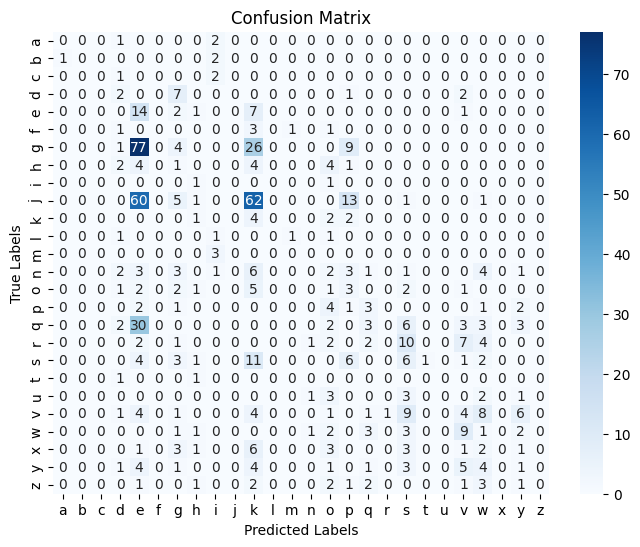

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import string

# Define the number of classes in your dataset
num_classes = len(np.unique(y_test_encoded))

# Generate a list of alphabets based on the number of classes
labels = list(string.ascii_lowercase)[:num_classes]


# Create the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Define the neural network model
model_nn = Sequential()
model_nn.add(Dense(12, input_shape=(X_train_scaled.shape[1],), activation='relu'))
model_nn.add(Dense(120, activation='relu'))
model_nn.add(Dense(240, activation='relu'))
model_nn.add(Dense(12, activation='relu'))
model_nn.add(Dense(len(np.unique(y_train)), activation='softmax'))

# Compile the model
model_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
# Split the training data into training and validation sets
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_scaled, y_train_encoded, test_size=0.2, random_state=42)

# Train the neural network on the train data
model_nn.fit(X_train_split, y_train_split, epochs=480, batch_size=12, validation_data=(X_val_split,y_val_split), verbose=1)


Epoch 1/480
36/36 [==============================] - 1s 15ms/step - loss: 1.5906 - accuracy: 0.4563 - val_loss: 6.9799 - val_accuracy: 0.2736
Epoch 2/480
36/36 [==============================] - 0s 12ms/step - loss: 1.7300 - accuracy: 0.4492 - val_loss: 4.0114 - val_accuracy: 0.2736
Epoch 3/480
36/36 [==============================] - 0s 9ms/step - loss: 1.6889 - accuracy: 0.4539 - val_loss: 3.5780 - val_accuracy: 0.3113
Epoch 4/480
36/36 [==============================] - 0s 7ms/step - loss: 1.5363 - accuracy: 0.4586 - val_loss: 3.4398 - val_accuracy: 0.3208
Epoch 5/480
36/36 [==============================] - 0s 7ms/step - loss: 1.4570 - accuracy: 0.4657 - val_loss: 3.5838 - val_accuracy: 0.3396
Epoch 6/480
36/36 [==============================] - 0s 11ms/step - loss: 1.5634 - accuracy: 0.4350 - val_loss: 4.4779 - val_accuracy: 0.3113
Epoch 7/480
36/36 [==============================] - 0s 9ms/step - loss: 1.4977 - accuracy: 0.4586 - val_loss: 3.4730 - val_accuracy: 0.3396
Epoch 8/48

In [ ]:
# Evaluate the loaded model on the validation set
val_loss, val_accuracy = model_nn.evaluate(X_val_split, y_val_split)

print(f"Validation Loss: {val_loss}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

4/4 [==============================] - 0s 5ms/step - loss: 6.7121 - accuracy: 0.3585
Validation Loss: 6.712102890014648
Validation Accuracy: 35.85%


In [ ]:
# Make predictions on the test data
y_pred_nn = model_nn.predict(X_test_scaled)
y_pred_nn_labels = np.argmax(y_pred_nn, axis=1)

# Calculate accuracy on the test data
accuracy_test_nn = accuracy_score(y_test_encoded, y_pred_nn_labels)
print(f"Accuracy on Test Data (Neural Network): {accuracy_test_nn * 100:.2f}%")

21/21 [==============================] - 0s 1ms/step
Accuracy on Test Data (Neural Network): 6.10%


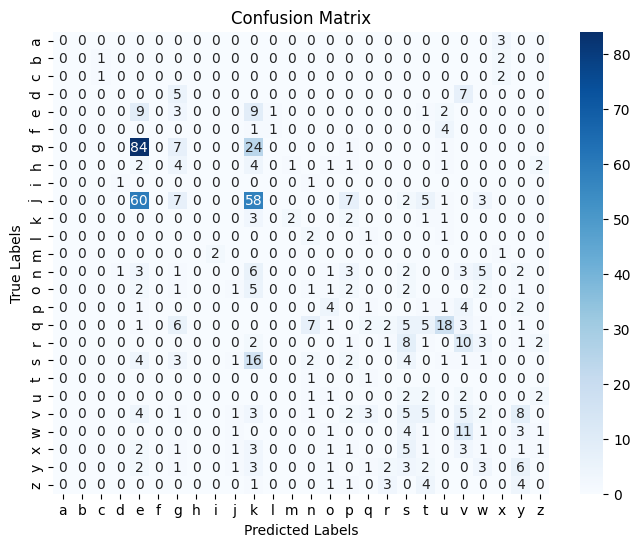

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

import string

# Define the number of classes in your dataset
num_classes = len(np.unique(y_test_encoded))

# Generate a list of alphabets based on the number of classes
labels = list(string.ascii_lowercase)[:num_classes]


# Create the confusion matrix
conf_matrix = confusion_matrix(y_test_encoded, y_pred_nn_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Decode numerical labels back to original class labels
predicted_classes = label_encoder_train.inverse_transform(np.argmax(y_pred_nn, axis=1))

# Print the predicted classes
print("Predicted Classes:", predicted_classes)

# Calculate accuracy on the test data
accuracy_test = accuracy_score(y_test_encoded, np.argmax(y_pred_nn, axis=1))
print(f"Accuracy on Test Data (Neural Network): {accuracy_test * 100:.2f}%")

# Check for consistency in label encoding
print("Unique classes in test set:", np.unique(y_test))
print("Unique classes in predicted set:", np.unique(predicted_classes))

Predicted Classes: ['c' 'x' 'x' 'x' 'x' 'x' 'c' 'x' 'x' 'g' 'g' 'v' 'v' 'v' 'v' 'g' 'v' 'v'
 'g' 'v' 'g' 'l' 'u' 'g' 'g' 'g' 'e' 'e' 'e' 'u' 'e' 'k' 'e' 'e' 'e' 'e'
 'k' 'k' 'k' 'k' 't' 'k' 'k' 'k' 'k' 'e' 'l' 'u' 'u' 'k' 'u' 'u' 'u' 'e'
 'k' 'e' 'k' 'e' 'k' 'e' 'k' 'g' 'g' 'g' 'e' 'e' 'e' 'k' 'e' 'k' 'e' 'e'
 'e' 'e' 'e' 'p' 'e' 'e' 'e' 'k' 'e' 'k' 'e' 'e' 'e' 'k' 'e' 'k' 'e' 'e'
 'k' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'k' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e'
 'e' 'k' 'e' 'e' 'e' 'k' 'k' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e'
 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'e' 'k' 'e' 'k' 'e' 'e' 'k'
 'e' 'k' 'e' 'k' 'k' 'k' 'e' 'k' 'e' 'e' 'e' 'e' 'e' 'k' 'g' 'e' 'g' 'g'
 'g' 'e' 'e' 'e' 'e' 'e' 'e' 'u' 'm' 'e' 'g' 'g' 'g' 'z' 'k' 'k' 'p' 'k'
 'k' 'e' 'o' 'g' 'z' 'n' 'd' 'u' 'e' 'e' 'k' 'k' 'e' 'e' 'p' 'e' 'p' 'g'
 'k' 'g' 't' 't' 'k' 'k' 'k' 'w' 'e' 'k' 'e' 'e' 't' 'e' 'e' 'e' 'e' 'e'
 'e' 'e' 'k' 'e' 'e' 'k' 'k' 'k' 'k' 'e' 'k' 'e' 'e' 'e' 'k' 'e' 'e' 'e'
 'k' 'k' 'k' 'k' 'e' 'k' 'e' 'e'

In [ ]:
import numpy as np
from sklearn.feature_selection import mutual_info_classif

def mrmr_score(X, y):
    n_features = X.shape[1]
    mrmr_scores = np.zeros(n_features)

    # Calculate mutual information between each feature and the target
    mi = mutual_info_classif(X, y)

    for i in range(n_features):
        mrmr_scores[i] = mi[i] - (1 / n_features) * np.sum(mi)

    return mrmr_scores

# Assuming X_train contains your training data with audio features and y_train contains corresponding labels
mrmr_scores = mrmr_score(X_train_scaled, y_train)

# Sort the features based on MRMR scores
sorted_indices = sorted(range(len(mrmr_scores)), key=lambda i: mrmr_scores[i], reverse=True)

# Print the indices and MRMR scores of all features
for i, score in enumerate(mrmr_scores):
    print("Index:", i, "MRMR Score:", score)


Index: 0 MRMR Score: 0.02406611836443212
Index: 1 MRMR Score: -0.034716167564151246
Index: 2 MRMR Score: 0.01065004919971918
